[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/exorbyte/mbox-cookbook/blob/main/05-explainability/02-reading_field_level_scores.ipynb)

In [1]:
# !pip install mbox

# Reading Field-Level Scores

You have been reading `_score` columns since the first notebook in this cookbook, and `01-index_types_and_recall_modes.ipynb` just introduced the `0`-`100` score as "the portion of a reasonable match." This notebook makes that concrete: how `APPROX` arrives at a number, why matches sometimes disappear entirely rather than just scoring low, and how `overall_score` combines every field into one number.

Every example below loads its data from `datasets/`, rather than building it inline. The queries you'll see, words with a known number of characters swapped out, were generated once and saved as CSVs, so the code here is about what M|BOX does with them, not about how they were made.

In this notebook you will learn:

1. How `APPROX` turns character-level differences into a 0 to 100 score
2. Why matches have a hard cutoff, and why that cutoff depends on field length
3. The exact formula behind `overall_score`
4. How to read every column `include_field_scores=True` and `include_queries=True` add to your results
5. Practical guidelines that follow directly from how scoring actually works

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from mbox.indexing import TableIndexer
from mbox.recall import TableRecallMode

mbpie: 33 modules, 566 methods, 8 classes, 18 enums
  args: 426 required, 254 optional, 37 keywords, 39 flags, 26 arrays
  types: 372 int, 337 str, 1 double, 72 object


## 1. How `APPROX` calculates a score

`APPROX` is built on Levenshtein distance, the number of single-character edits (insertions, deletions, substitutions) needed to turn your query into the indexed value. Fewer edits relative to the length of the string produce a higher score; more edits produce a lower one.

`datasets/single_word_index.csv` is the one value we'll index throughout this section: a 13-character word.

In [3]:
word_df = pd.read_csv("datasets/single_word_index.csv")
word_df

,word
0,APPROXIMATELY


`datasets/single_word_edit_queries.csv` holds the queries we'll run against it, seven versions of the same word, with `0` through `6` characters swapped for a placeholder letter at fixed positions. `edits` tells you how many characters differ from the original.

In [4]:
edit_queries = pd.read_csv("datasets/single_word_edit_queries.csv")
edit_queries

,edits,query
0,0,APPROXIMATELY
1,1,APPROXQMATELY
2,2,APPROXQMATELQ
3,3,QPPROXQMATELQ
4,4,QPPRQXQMATELQ
5,5,QPPRQXQMQTELQ
6,6,QPPRQXQQQTELQ


Build the index from `word_df`, then match all five of the low-edit queries at once by passing the `query` column straight to `.match()` as a batch.

In [5]:
index = TableIndexer.create_index(word_df, index_columns=["word"], tmp_dir="tmp_index")

low_edit_queries = edit_queries[edit_queries["edits"] <= 4]
result = index.match(
    queries=low_edit_queries[["query"]].rename(columns={"query": "word"}),
    include_field_scores=True,
    min_total_match_value=0
)

low_edit_queries[["edits", "query"]].assign(word_score=result["word_score"].values)

,edits,query,word_score
0,0,APPROXIMATELY,100
1,1,APPROXQMATELY,87
2,2,APPROXQMATELQ,74
3,3,QPPROXQMATELQ,60
4,4,QPPRQXQMATELQ,45


A perfect match scores `100`. Each additional edit lowers the score by roughly the same amount, here, about 13 to 15 points per edit on a 13-character word. This is the core behavior to remember: `APPROX` is measuring edit distance relative to string length, not just counting how many letters happen to overlap.

One detail worth pinning down before going further: which `IndexType` is `"word"` actually using here? There is only one column, and its values contain no spaces, so `TableIndexer` infers `IndexType.TERM`, not `PHRASE`.

In [6]:
print(index.get_index_config().get_field("word").index_type)

IndexType.TERM


Everything in this notebook, the numbers above, the cutoff behavior in Section 2, is specifically `TERM`'s version of `APPROX`. `01-index_types_and_recall_modes.ipynb` already showed `PHRASE` and `IDENT` scoring this same word slightly differently under the same edits, and `03-phrase_fields_explained.ipynb` through `05-ident_fields_explained.ipynb` go through each `IndexType` in full. Nothing here contradicts those notebooks, it's the same mechanism, one specific `IndexType` at a time.

`APPROX` is the only line that slopes downward gradually, it is genuinely measuring degrees of similarity. `EXACT`, `COMPLETE`, and `DETECT` all drop straight to `0` after the very first edit, and stay there. That is the visual version of the distinction above: `APPROX` gives you a graded signal, the other three modes give you a yes-or-no answer, and no amount of "almost" changes that. Notice that `index.match()` never had to be told a query was "not found," a query that fails simply comes back with `word_score = 0`, which is exactly what let this chart use one batched call per mode instead of one call per data point.

## 2. The hard cutoff: matches disappear, they do not fade to zero

There is a limit to how many edits `APPROX` will tolerate. Past that limit, a candidate is not returned with a low score, it is not returned at all. `index_row` becomes `-1`, and every score column reads `0`.

This limit scales with the length of the field. `datasets/word_length_index.csv` holds five words of very different lengths, all `TERM` fields, the same `IndexType` as Section 1, to test that directly.

In [7]:
words_df = pd.read_csv("datasets/word_length_index.csv")
words_df

,word
0,CAT
1,APPROXIMATE
2,APPROXIMATELY
3,APPROXIMATIONS
4,SUPERCALIFRAGILISTIC


`datasets/word_length_edit_queries.csv` holds, for each word, a run of queries with `0` up to `10` characters swapped, comfortably past where every one of these words' matches disappears.

In [8]:
length_queries = pd.read_csv("datasets/word_length_edit_queries.csv")
length_queries.head(8)

,indexed_word,edits,query
0,CAT,0,CAT
1,CAT,1,CQT
2,CAT,2,CQQ
3,CAT,3,QQQ
4,APPROXIMATE,0,APPROXIMATE
5,APPROXIMATE,1,APPROXQMATE
6,APPROXIMATE,2,APPROXQMATQ
7,APPROXIMATE,3,QPPROXQMATQ


Each word gets its own single-row index, the same setup as Section 1, so one word's cutoff can never be influenced by another word sitting in the same index. For each word, batch-match every one of its pre-built queries in a single call, then read off the highest `edits` value that still cleared the threshold.

In [9]:
rows = []
for word in words_df["word"]:
    word_index = TableIndexer.create_index(pd.DataFrame({"word": [word]}), index_columns=["word"], tmp_dir="tmp_index")
    queries_for_word = length_queries[length_queries["indexed_word"] == word]

    result = word_index.match(
        queries=queries_for_word[["query"]].rename(columns={"query": "word"}),
        include_field_scores=True,
        min_total_match_value=0
    )
    matched_edits = queries_for_word["edits"].values[result["index_row"].values != -1]
    rows.append({"word": word, "length": len(word), "max_tolerated_edits": matched_edits.max()})

cutoff_df = pd.DataFrame(rows)
cutoff_df

,word,length,max_tolerated_edits
0,CAT,3,0
1,APPROXIMATE,11,3
2,APPROXIMATELY,13,4
3,APPROXIMATIONS,14,5
4,SUPERCALIFRAGILISTIC,20,8


`"CAT"`, three characters long, tolerates zero edits, a single typo loses the match completely. `"SUPERCALIFRAGILISTIC"`, twenty characters long, tolerates far more. Longer fields give `APPROX` more room to work with before hitting its limit. It's worth seeing that this isn't just a loose trend, it's close to a straight line.

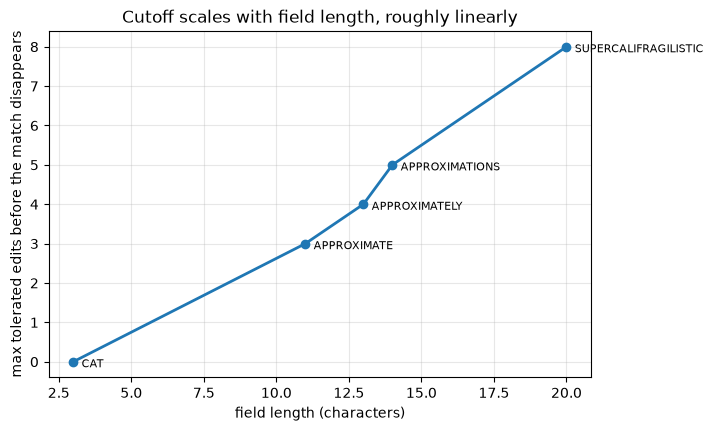

In [10]:
plt.figure(figsize=(7, 4.5))
plt.plot(cutoff_df["length"], cutoff_df["max_tolerated_edits"], marker="o", linewidth=2)
for _, row in cutoff_df.iterrows():
    plt.annotate(row["word"], (row["length"], row["max_tolerated_edits"]), textcoords="offset points", xytext=(6, -4), fontsize=8)
plt.xlabel("field length (characters)")
plt.ylabel("max tolerated edits before the match disappears")
plt.title("Cutoff scales with field length, roughly linearly")
plt.grid(True, alpha=0.3)
plt.show()

This is the practical reason `04-recall-tuning/01-understanding_match_modes.ipynb` and `05-ident_fields_explained.ipynb` both warn against leaning on `APPROX` for short identifiers: it isn't that short fields are treated unfairly, it's that the same proportional rule applies everywhere, and a short field simply doesn't have enough length for that proportion to add up to more than zero or one tolerated edit.

## 3. How `overall_score` combines fields

When you query more than one field, `overall_score` is the weighted average of each field's individual score:

```
overall_score = floor( (weight_field_1 * score_field_1 / 100) + (weight_field_2 * score_field_2 / 100) + ... )
```

when weights sum to 100. `datasets/weighting_two_candidates.csv` holds two products built to make this concrete: one whose name is a strong match for our query, and one whose description is.

In [11]:
candidates_df = pd.read_csv("datasets/weighting_two_candidates.csv")
candidates_df

,product_name,description
0,Extended Battery Pack,Compact accessory offering extended battery li...
1,Extended Cell Battery,Extended battery pack accessory for compact ca...


Index both rows, then run the identical query, `product_name` and `description` both set to `"Extended Battery Pack"`, under three different weight splits.

In [12]:
catalog_index = TableIndexer.create_index(candidates_df, index_columns=["product_name", "description"], tmp_dir="tmp_index")
query = pd.DataFrame({"product_name": ["Extended Battery Pack"], "description": ["Extended Battery Pack"]})

rows = []
for weights in [{"product_name": 50, "description": 50},
                {"product_name": 90, "description": 10},
                {"product_name": 10, "description": 90}]:
    results = catalog_index.match(
        queries=query,
        weights=weights,
        include_field_scores=True,
        min_total_match_value=0,
        max_results=2
    )
    for _, row in results.iterrows():
        predicted = (row["product_name_score"] * weights["product_name"]
                     + row["description_score"] * weights["description"]) / 100
        rows.append({
            "weights": weights,
            "candidate": row["product_name_candidate"],
            "overall_score": row["overall_score"],
            "name_score": row["product_name_score"],
            "desc_score": row["description_score"],
            "predicted_weighted_avg": round(predicted, 1)
        })

pd.DataFrame(rows)

,weights,candidate,overall_score,name_score,desc_score,predicted_weighted_avg
0,"{'product_name': 50, 'description': 50}",Extended Battery Pack,64,100,29,64.5
1,"{'product_name': 50, 'description': 50}",Extended Cell Battery,64,42,86,64.0
2,"{'product_name': 90, 'description': 10}",Extended Battery Pack,92,100,29,92.9
3,"{'product_name': 90, 'description': 10}",Extended Cell Battery,46,42,86,46.4
4,"{'product_name': 10, 'description': 90}",Extended Cell Battery,81,42,86,81.6
5,"{'product_name': 10, 'description': 90}",Extended Battery Pack,36,100,29,36.1


`predicted_weighted_avg` matches `overall_score` in every row, confirming the formula directly. Once you know this, you can predict how a weight change will affect ranking without running a query first, which is exactly what `04-recall-tuning/02-weighting_fields_for_better_precision.ipynb` relies on, and exactly what breaks down in one specific, testable edge case in `07-multi_field_weights_explained.ipynb`.

### Visualizing the crossover

The three weight splits above are just three points along a continuous scale. It's worth seeing the full picture: as weight shifts from fully favoring `description` to fully favoring `product_name`, at what point does the ranking between our two candidates actually flip? The 50/50 result already contains both candidates' individual field scores, pull them out directly rather than retyping them.

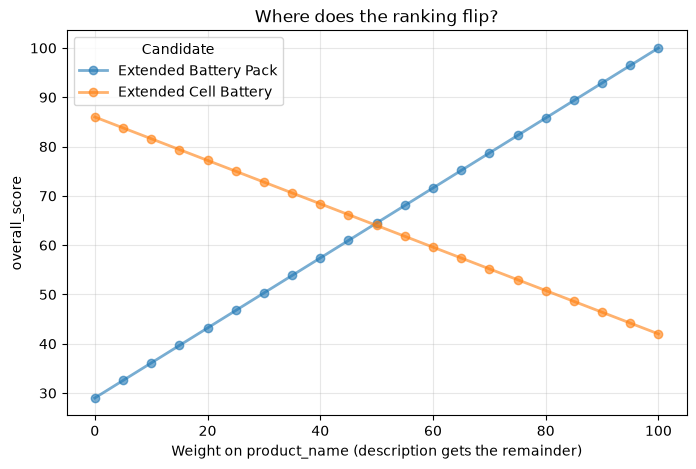

In [13]:
equal_weight_result = catalog_index.match(queries=query, weights={"product_name": 50, "description": 50}, include_field_scores=True, min_total_match_value=0, max_results=2)
candidate_scores = {
    row["product_name_candidate"]: {"name_score": row["product_name_score"], "desc_score": row["description_score"]}
    for _, row in equal_weight_result.iterrows()
}

name_weights = list(range(0, 101, 5))
plt.figure(figsize=(8, 5))
for candidate, scores in candidate_scores.items():
    overall_scores = [
        (scores["name_score"] * w + scores["desc_score"] * (100 - w)) / 100
        for w in name_weights
    ]
    plt.plot(name_weights, overall_scores, marker="o", label=candidate, alpha=0.6, linewidth=2)

plt.xlabel("Weight on product_name (description gets the remainder)")
plt.ylabel("overall_score")
plt.title("Where does the ranking flip?")
plt.legend(title="Candidate")
plt.grid(True, alpha=0.3)
plt.show()

The two lines cross exactly once. To the left of that point, `description` carries more weight and `"Extended Cell Battery"` ranks higher. To the right, `product_name` carries more weight and `"Extended Battery Pack"` takes over. Right at the crossing point, the two candidates are tied, which is exactly what you saw at the default 50/50 split earlier: `overall_score = 64` for both.

This is the practical value of knowing `overall_score` is a plain weighted average: the crossover point isn't a mystery you'd have to discover by trial and error, it's just algebra. Given two candidates' field scores, pulled directly from one real query rather than guessed, you can solve for the weight split where they tie, rather than nudging weights and re-running queries until something changes.

## 4. Every column, explained

`include_field_scores=True` and `include_queries=True` add columns beyond the basics. Here is what each one means:

| Column | Meaning |
|---|---|
| `query_row` | Which row of your input query this result corresponds to |
| `index_row` | Which row of your original indexed data this candidate came from, `-1` if no candidate was found at all |
| `overall_score` | The weighted average of every searched field's score, see Section 3 |
| `<field>_candidate` | The actual value stored in the index for this field |
| `<field>_query` | The raw value you searched with, only present when `include_queries=True` |
| `<field>_score` | This field's individual score, 0 to 100, see Sections 1 and 2 for how it is calculated |

A row with `index_row = -1` means no candidate cleared the internal matching threshold for at least one of the fields you searched, not that a candidate was found and scored poorly. Distinguishing these two cases matters when you are debugging why a query returned nothing, covered next in `08-debugging_a_bad_match.ipynb`.

## 5. Practical guidelines that follow from this

**Do not rely on `APPROX` for very short fields.** A field of three or four characters has almost no room for edits before the cutoff eliminates the match entirely, and Section 2's chart shows this is a predictable consequence of field length, not bad luck. Initials, short codes, and two-letter abbreviations are usually better matched with `IDENT` or `EXACT`, covered in `04-recall-tuning/01-understanding_match_modes.ipynb` and `05-ident_fields_explained.ipynb`, where a deliberate design choice makes more sense than relying on fuzziness that barely has room to operate.

**Longer fields tolerate more noise, but still have a limit.** If your data is likely to contain heavy noise, OCR errors, garbled scans, transliteration mismatches, consider whether character-level harmonization from `02-data-harmonization/` should reduce that noise before matching, rather than expecting `APPROX` alone to absorb an unlimited amount of it.

**You can calculate the weight split needed to favor one candidate over another.** Since `overall_score` is a confirmed weighted average, if you know two candidates' individual field scores, you can solve directly for the weight split that would rank one above the other, rather than adjusting weights by trial and error.

**`index_row = -1` is a specific, meaningful signal.** It tells you no candidate cleared the threshold for at least one searched field, which is different from "a candidate was found but scored 0." Recognizing this distinction is the first step in diagnosing an unexpectedly empty result, which the last notebook in this directory walks through directly.

## Next steps

- **`03-phrase_fields_explained.ipynb`** through **`06-numeric_fields_explained.ipynb`** - now that you know how scores and cutoffs actually work, see what they mean for your specific `IndexType`
- **`07-multi_field_weights_explained.ipynb`** - how weights combine field scores of different `IndexType`s into `overall_score`
- **`08-debugging_a_bad_match.ipynb`** - walk through a real match that goes wrong, and use what you just learned to diagnose exactly why

*M|BOX is currently in `beta`. Breaking changes may occur in minor releases until version `1.0.0`.*